# Neural Machine Translation by Jointly Learning to Align and Translate

# https://arxiv.org/pdf/1409.0473

## Abstract
This paper introduces an extension to the standard encoder–decoder framework for neural machine translation (NMT) that allows the model to automatically search for relevant parts of a source sentence when predicting each target word, rather than compressing the entire source sentence into a single fixed-length vector. The proposed model, RNNsearch, jointly learns alignment and translation, achieving performance comparable to a conventional phrase-based statistical machine translation (SMT) system on English-to-French translation, with qualitative alignment analysis confirming linguistically plausible soft alignments.

## Problems
- Conventional encoder–decoder NMT models compress a variable-length source sentence into a single fixed-length context vector $$c$$.
- This fixed-length representation is a bottleneck: performance deteriorates rapidly as source sentence length increases, especially beyond lengths seen during training.
- The basic encoder–decoder architecture struggles to retain all necessary information for long sentences, limiting translation quality.

## Proposed Solutions
- An extended architecture that computes a distinct context vector $$c_i$$ for each target word $$y_i$$, rather than a single vector for the whole sentence.
- A bidirectional RNN (BiRNN) encoder that produces a sequence of annotations $$(h_1, \dots, h_{T_x})$$, each summarizing both preceding and following words via concatenation of forward and backward hidden states:
$$h_j = \left[\overrightarrow{h}_j^{\top}; \overleftarrow{h}_j^{\top}\right]^{\top}$$
- A soft-alignment (attention) mechanism where the context vector is a weighted sum of annotations:
$$c_i = \sum_{j=1}^{T_x} \alpha_{ij} h_j, \quad \alpha_{ij} = \frac{\exp(e_{ij})}{\sum_{k=1}^{T_x} \exp(e_{ik})}, \quad e_{ij} = a(s_{i-1}, h_j)$$
- The alignment model $$a$$ is a feedforward neural network jointly trained with the rest of the system, computing $$e_{ij}$$ from the previous decoder state and each annotation, enabling end-to-end gradient-based training of alignment and translation together.

## Purpose
To overcome the fixed-length vector bottleneck in encoder–decoder NMT by allowing the model to adaptively select relevant source information for each target word, improving translation quality—particularly for long sentences—while retaining a fully neural, jointly trainable architecture.

## Methodology
- **Task and data**: English-to-French translation using WMT '14 parallel corpora (Europarl, news commentary, UN, and two crawled corpora), reduced to 348M words via a data selection method; validation from news-test-2012/2013; test set is news-test-2014 (3003 sentences).
- **Vocabulary**: 30,000 most frequent words per language; out-of-vocabulary words mapped to an [UNK] token; no lowercasing or stemming applied.
- **Models compared**:
  - RNNencdec: conventional RNN Encoder–Decoder (Cho et al., 2014a) with 1000 hidden units each for encoder and decoder.
  - RNNsearch: the proposed model, with a bidirectional encoder (1000 hidden units per direction) and a 1000-unit decoder.
- Each model type trained twice, on sentences up to length 30 (RNNencdec-30, RNNsearch-30) and up to length 50 (RNNencdec-50, RNNsearch-50).
- **Training**: minibatch stochastic gradient descent with Adadelta, minibatches of 80 sentences, approximately 5 days of training per model; gated hidden units (similar to LSTM) used as the RNN activation function; decoding via beam search.
- **Architecture details**: single-layer maxout hidden layer for computing output word probabilities; alignment model uses a single-layer MLP with precomputable terms to reduce computation, since it must be evaluated $$T_x \times T_y$$ times per sentence pair.
- **Evaluation**: BLEU score, computed both on all sentences and on the subset without unknown words.

## Results
- RNNsearch consistently outperforms RNNencdec across all settings.
- Quantitative BLEU scores (from Table 1):

| Model | BLEU (All) | BLEU (No UNK) |
|---|---|---|
| RNNencdec-30 | 13.93 | 24.19 |
| RNNsearch-30 | 21.50 | 31.44 |
| RNNencdec-50 | 17.82 | 26.71 |
| RNNsearch-50 | 26.75 | 34.16 |
| RNNsearch-50 (extended training) | 28.45 | 36.15 |
| Moses (phrase-based SMT) | 33.30 | 35.63 |

- RNNsearch-50 matches Moses performance on sentences without unknown words, despite Moses using an additional 418M-word monolingual corpus.
- RNNsearch-30 outperforms RNNencdec-50, demonstrating robustness independent of maximum training sentence length.
- Performance of RNNencdec degrades sharply as sentence length increases, while RNNsearch-50 shows no degradation even at length 50+.
- Qualitative alignment visualizations show largely monotonic English-French alignments with correctly captured non-monotonic cases (e.g., adjective-noun reordering) and soft alignments handling many-to-many word correspondences (e.g., "the man" to "l' homme") better than rigid hard alignments.
- Sample long-sentence translations show RNNsearch preserving full meaning where RNNencdec deviates from the source after roughly 30 words.

## Conclusions
- The fixed-length context vector is a genuine limitation of the basic encoder–decoder approach for long sentences.
- Jointly learning to align and translate via a soft-attention mechanism over a sequence of encoder annotations resolves this bottleneck, freeing the model from encoding the entire sentence into one vector.
- The proposed RNNsearch architecture significantly and consistently outperforms RNNencdec, and achieves translation quality comparable to a strong phrase-based SMT baseline, despite being a purely neural, end-to-end trained system.
- The attention mechanism yields interpretable soft alignments that align well with linguistic intuition.
- Remaining challenges include better handling of unknown and rare words to further close the gap with state-of-the-art SMT systems.

# Mathematical and Statistical Content Summary

## 1. Conditional Probability of Translation
$$p(\mathbf{y}) = \prod_{t=1}^{T} p(y_t \mid \{y_1, \dots, y_{t-1}\}, c)$$
Translation is framed as predicting each target word one at a time, conditioned on all previously generated words and a context representation $$c$$ of the source sentence. This is the standard factorization of sequence probability used in all sequence-generation models.

## 2. Basic RNN Encoder Recurrence
$$h_t = f(x_t, h_{t-1})$$
The encoder reads the source sentence word by word, updating a hidden state $$h_t$$ at each step using the current input and the previous hidden state. $$f$$ is a nonlinear function (here, a gated recurrent unit).

## 3. Fixed-Length Context Vector (Baseline)
$$c = q(\{h_1, \dots, h_{T_x}\})$$
In the conventional encoder–decoder, all hidden states are compressed into a single vector $$c$$ (e.g., simply the last hidden state). This is identified as the main bottleneck the paper addresses.

## 4. Decoder Output Probability (General Form)
$$p(y_t \mid \{y_1,\dots,y_{t-1}\}, c) = g(y_{t-1}, s_t, c)$$
The probability of the next word depends on the previous word, the decoder's own hidden state $$s_t$$, and the context vector, via a nonlinear (possibly multi-layer) function $$g$$.

## 5. Proposed Per-Word Context Vector
$$p(y_i \mid y_1,\dots,y_{i-1}, \mathbf{x}) = g(y_{i-1}, s_i, c_i), \qquad s_i = f(s_{i-1}, y_{i-1}, c_i)$$
The key modification: instead of one context vector for the whole sentence, a distinct context vector $$c_i$$ is computed for each target word, allowing the decoder to focus on different source information at each decoding step.

## 6. Context Vector as Weighted Sum of Annotations
$$c_i = \sum_{j=1}^{T_x} \alpha_{ij} h_j$$
Each source-side annotation $$h_j$$ (encoding information around word $$j$$) is combined via a weighted average, where weights $$\alpha_{ij}$$ indicate how relevant source word $$j$$ is to generating target word $$i$$. This is the core "attention" computation.

## 7. Alignment Weights (Softmax Normalization)
$$\alpha_{ij} = \frac{\exp(e_{ij})}{\sum_{k=1}^{T_x} \exp(e_{ik})}$$
The softmax function converts raw alignment scores $$e_{ij}$$ into a probability distribution over source positions, ensuring the weights are non-negative and sum to 1. This allows $$\alpha_{ij}$$ to be interpreted as the probability that target word $$i$$ aligns to source word $$j$$.

## 8. Alignment (Energy) Score
$$e_{ij} = a(s_{i-1}, h_j)$$
A learned scoring function that measures compatibility between the decoder's previous state and each source annotation. Implemented as a single-layer feedforward network:
$$a(s_{i-1}, h_j) = v_a^{\top} \tanh(W_a s_{i-1} + U_a h_j)$$
where $$W_a$$, $$U_a$$, $$v_a$$ are learned weight matrices/vectors. Since $$U_a h_j$$ does not depend on $$i$$, it can be precomputed once per sentence to reduce computation across the $$T_x \times T_y$$ evaluations required.

## 9. Bidirectional Encoder Annotation
$$h_j = \left[\overrightarrow{h}_j^{\top}; \overleftarrow{h}_j^{\top}\right]^{\top}$$
Each annotation concatenates a forward hidden state (summarizing preceding words) and a backward hidden state (summarizing following words), so each word's representation carries context from the whole sentence, not just one direction.

## 10. Gated Hidden Unit (GRU-like Recurrence)
Used for both encoder and decoder recurrent computations:
$$s_i = (1 - z_i) \circ s_{i-1} + z_i \circ \tilde{s}_i$$
$$\tilde{s}_i = \tanh(W e(y_{i-1}) + U[r_i \circ s_{i-1}] + C c_i)$$
$$z_i = \sigma(W_z e(y_{i-1}) + U_z s_{i-1} + C_z c_i)$$
$$r_i = \sigma(W_r e(y_{i-1}) + U_r s_{i-1} + C_r c_i)$$
- $$\circ$$ denotes element-wise multiplication.
- The **update gate** $$z_i$$ (via sigmoid $$\sigma$$) controls how much of the previous state is retained versus replaced by the new candidate state $$\tilde{s}_i$$.
- The **reset gate** $$r_i$$ controls how much past information is used when computing the candidate state.
- This gating mechanism helps the RNN better capture long-range dependencies by allowing gradients to flow without excessive vanishing, addressing the vanishing gradient problem in standard RNNs.

## 11. Output Word Probability (Deep Output Layer)
$$p(y_i \mid s_i, y_{i-1}, c_i) \propto \exp\left(y_i^{\top} W_o t_i\right)$$
with $$t_i$$ built from a maxout operation over pairs of elements of a linear combination of the decoder state, previous word embedding, and context vector. This is a multi-layered (deep) output function that increases model expressiveness before applying softmax over the vocabulary.

## 12. Training Objective and Optimization
- **Stochastic Gradient Descent (SGD)** with minibatches of 80 sentences is used to minimize the negative log-likelihood of correct translations.
- **Adadelta** is used to adaptively set per-parameter learning rates, using hyperparameters $$\epsilon = 10^{-6}$$ and $$\rho = 0.95$$.
- **Gradient norm clipping**: the L2-norm of the gradient is rescaled to a threshold of 1 whenever it exceeds this value, to stabilize training and prevent exploding gradients.

## 13. Parameter Initialization
- Recurrent weight matrices initialized as random **orthogonal matrices** (helps preserve gradient magnitude through recurrence).
- Alignment model weights ($$W_a$$, $$U_a$$) initialized from a Gaussian distribution with mean 0 and variance $$0.001^2$$.
- Other weight matrices initialized from a Gaussian distribution with mean 0 and variance $$0.01^2$$.
- All bias vectors and $$v_a$$ initialized to zero.

## 14. Evaluation Metric: BLEU Score
BLEU (Bilingual Evaluation Understudy) is used as the primary statistical evaluation metric, comparing n-gram overlap between machine-generated translations and reference translations. Scores are reported both over the full test set and restricted to sentences without unknown words, enabling fair comparison across models with different vocabulary coverage.

## 15. Training Statistics (Negative Log-Likelihood)
The paper reports average conditional log-probabilities (NLL) on training and development sets as an auxiliary statistical measure of model fit, alongside epoch counts and update counts, to characterize convergence behavior across models (Table 2).

## Role Summary
| Concept | Role in Paper |
|---|---|
| Conditional probability factorization | Defines the translation generation process |
| Fixed vs. per-word context vector | Frames the core problem and proposed fix |
| Softmax alignment weights | Produces interpretable "soft" alignment (attention) |
| Feedforward alignment scoring function | Learns which source words matter for each target word |
| Bidirectional RNN annotations | Ensures full-sentence context for every source word |
| Gated hidden units | Enables stable learning of long-range dependencies |
| Maxout deep output | Increases decoder expressiveness |
| Adadelta, gradient clipping | Ensures stable, adaptive optimization |
| BLEU score | Quantifies translation quality for evaluation |

# Problems, Limitations, and Proposed Solutions

| # | Key Problem / Research Gap | How This Limits Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | Conventional encoder–decoder NMT models compress an entire variable-length source sentence into a single fixed-length context vector $$c$$. | The network must squeeze all semantic and syntactic information into one vector regardless of sentence length, creating an information bottleneck that constrains representational capacity. | Replace the single fixed-length vector with a sequence of annotations $$(h_1, \dots, h_{T_x})$$ and compute a distinct, adaptively weighted context vector $$c_i$$ for each target word, avoiding the need to encode the whole sentence into one representation. |
| 2 | Translation performance of basic encoder–decoder models (e.g., Cho et al., 2014a) deteriorates rapidly as source sentence length increases, particularly beyond lengths seen in training. | Prior models are unreliable for long or complex sentences, limiting practical applicability to real-world text, which often contains long sentences. | Introduce a soft-search (attention) mechanism that lets the decoder selectively retrieve relevant source annotations at each decoding step, making performance robust across sentence lengths (demonstrated for RNNsearch-50 up to 50+ words). |
| 3 | Standard RNN encoders process the source sentence in a single (forward) direction, so each hidden state $$h_t$$ mainly reflects preceding context. | Annotations biased toward one direction may not adequately capture context from words that appear later in the sentence, weakening representation quality for words requiring bidirectional context (e.g., agreement, word order differences between languages). | Employ a bidirectional RNN (BiRNN) encoder that concatenates forward and backward hidden states, $$h_j = [\overrightarrow{h}_j^\top; \overleftarrow{h}_j^\top]^\top$$, so each annotation summarizes the whole input sequence with a local focus. |
| 4 | Hard (one-to-one) alignment methods used in traditional statistical machine translation cannot naturally represent one-to-many, many-to-one, or context-dependent word correspondences (e.g., translating "the" differently depending on the following noun's gender). | Hard alignments require artificial constructs such as NULL alignments and cannot flexibly handle source and target phrases of different lengths or structures. | Use a soft-alignment model that computes continuous attention weights $$\alpha_{ij}$$ over all source words for each target word, allowing the decoder to attend to multiple relevant positions simultaneously and be trained end-to-end via backpropagation. |
| 5 | In earlier neural approaches (e.g., Graves, 2013, for handwriting synthesis), alignment is restricted to move monotonically in one direction. | Such monotonicity constraints are unsuitable for machine translation, where long-distance reordering is frequently required (e.g., English-to-German or adjective–noun reordering in English–French). | Design an unconstrained alignment model $$e_{ij} = a(s_{i-1}, h_j)$$, implemented as a feedforward network, that can assign attention to any source position regardless of order, capturing non-monotonic alignments. |
| 6 | Most prior neural components in machine translation are used only as auxiliary features or rerankers within existing statistical machine translation (SMT) pipelines (e.g., Schwenk, 2012; Devlin et al., 2014), rather than as complete standalone translation systems. | This limits neural networks to incremental improvements over SMT rather than realizing the full potential of end-to-end trainable translation models. | Propose a fully neural, end-to-end architecture (RNNsearch) that performs translation directly from source to target without relying on a separate SMT system, jointly training alignment and translation objectives. |
| 7 | Evaluation of the fixed-length vector bottleneck lacked direct quantitative and qualitative evidence linking sentence length to degraded translation quality. | Without clear diagnostic evidence, it is difficult to determine whether architecture modifications genuinely resolve the length-related weakness or merely improve overall averages. | Conduct systematic BLEU evaluation across sentence lengths (Fig. 2) and qualitative alignment visualization (Fig. 3) to directly demonstrate that RNNsearch mitigates performance degradation for long sentences while retaining interpretable alignments. |

In [1]:
# ============================================================================
# EDUCATIONAL REPLICATION: "Neural Machine Translation by Jointly Learning
# to Align and Translate" (Bahdanau, Cho, Bengio, 2015) — RNNsearch model
# ----------------------------------------------------------------------------
# NOTE ON DATASET: This paper is a sequence-to-sequence MACHINE TRANSLATION
# model (bidirectional RNN encoder + Bahdanau attention + RNN decoder).
# Instead we build a small SYNTHETIC parallel-sequence translation task
# in-code (source sequence -> reordered/transformed target sequence). This
# lets the attention mechanism form real, non-trivial (non-monotonic)
# soft-alignments, exactly like the alignment matrices in Figure 3 of the
# paper, and lets the dashboard's confusion matrix / per-class accuracy
# panels operate over the target VOCABULARY TOKENS (the actual "classes"
# a translation model predicts at each decoding step).
# ============================================================================

import io
import math
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from IPython.display import display, Image as IPImage

# ----------------------------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# ============================================================================
# 1) DATASET PREPARATION
# ----------------------------------------------------------------------------
# We define a tiny synthetic "language pair":
#   - Source vocabulary: 10 word-tokens (playing the role of "classes")
#   - Target vocabulary: the SAME 10 word-tokens, but the target sequence is
#     a REVERSAL of the source sequence. Reversal forces the model to learn
#     a genuinely NON-MONOTONIC alignment (like adjective/noun reordering
#     in the paper), which is exactly what the Bahdanau attention mechanism
#     is designed to discover and visualize.
# ============================================================================

# These 10 tokens double as our "class names" for the confusion-matrix /
# per-class-accuracy panels (mirrors the 10-class structure requested).
CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]
NUM_CLASSES = len(CLASS_NAMES)  # 10 "content" tokens

PAD, SOS, EOS = 0, 1, 2
NUM_SPECIAL = 3
VOCAB_SIZE = NUM_SPECIAL + NUM_CLASSES  # special tokens + 10 word tokens

MIN_LEN, MAX_LEN = 4, 8  # source sentence length range


def make_pair():
    """Generate one (source, target) synthetic sentence pair.
    Target = reversed source (word-for-word), forcing non-monotonic alignment.
    Tokens are offset by NUM_SPECIAL so 0/1/2 stay reserved for PAD/SOS/EOS.
    """
    length = random.randint(MIN_LEN, MAX_LEN)
    src = [random.randint(0, NUM_CLASSES - 1) + NUM_SPECIAL for _ in range(length)]
    tgt = list(reversed(src))
    return src, tgt


class SyntheticTranslationDataset(Dataset):
    """A PyTorch Dataset wrapping our synthetic parallel corpus.
    Each item returns (source_tensor, target_input_tensor, target_output_tensor).
    target_input starts with SOS (teacher forcing input to decoder),
    target_output ends with EOS (what the decoder must predict).
    """

    def __init__(self, num_samples, max_len=MAX_LEN):
        self.samples = [make_pair() for _ in range(num_samples)]
        self.max_len = max_len

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        src, tgt = self.samples[idx]
        tgt_in = [SOS] + tgt
        tgt_out = tgt + [EOS]
        return (torch.tensor(src, dtype=torch.long),
                torch.tensor(tgt_in, dtype=torch.long),
                torch.tensor(tgt_out, dtype=torch.long))


def collate_fn(batch):
    """Pads variable-length source/target sequences within a batch to the
    same length so they can be stacked into a single tensor."""
    srcs, tgt_ins, tgt_outs = zip(*batch)

    def pad_stack(seqs):
        max_len = max(s.size(0) for s in seqs)
        out = torch.full((len(seqs), max_len), PAD, dtype=torch.long)
        for i, s in enumerate(seqs):
            out[i, :s.size(0)] = s
        return out

    return pad_stack(srcs), pad_stack(tgt_ins), pad_stack(tgt_outs)


# Build train / validation (used as "test") splits, mirroring the requested
# sample-count conventions (train >> eval subset).
train_dataset = SyntheticTranslationDataset(num_samples=2000)
val_dataset = SyntheticTranslationDataset(num_samples=400)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=0, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, collate_fn=collate_fn)

# --- Sanity check -----------------------------------------------------------
sample_src, sample_tin, sample_tout = next(iter(train_loader))
print("Number of training samples:", len(train_dataset))
print("Number of validation/test samples:", len(val_dataset))
print("Shape of one batch (src, tgt_in, tgt_out):",
      sample_src.shape, sample_tin.shape, sample_tout.shape)
print("Token id range in batch (excluding PAD=0):",
      sample_src[sample_src != PAD].min().item(), "-", sample_src.max().item())
print("First 8 'class' tokens in batch (as class names):",
      [CLASS_NAMES[(t.item() - NUM_SPECIAL) % NUM_CLASSES] for t in sample_src[0][:8]])

Number of training samples: 2000
Number of validation/test samples: 400
Shape of one batch (src, tgt_in, tgt_out): torch.Size([64, 8]) torch.Size([64, 9]) torch.Size([64, 9])
Token id range in batch (excluding PAD=0): 3 - 12
First 8 'class' tokens in batch (as class names): ['dog', 'cat', 'dog', 'cat', 'horse', 'horse', 'horse', 'horse']


In [3]:
# ============================================================================
# 2) MODEL DEFINITION  (RNNsearch: BiRNN encoder + Bahdanau attention decoder)
# ============================================================================

class Encoder(nn.Module):
    """Bidirectional GRU encoder (Sec. 3.2 of the paper).
    Reads the source sentence in both directions and produces one
    'annotation' h_j per source word by concatenating forward/backward
    hidden states: h_j = [ ->h_j ; <-h_j ].
    """

    def __init__(self, vocab_size, emb_dim=64, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.hidden_dim = hidden_dim

    def forward(self, src, src_lengths):
        # src: (batch, src_len)
        embedded = self.embedding(src)  # (batch, src_len, emb_dim)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, hidden = self.gru(packed)
        annotations, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        # annotations: (batch, src_len, 2*hidden_dim)  -> concatenated fwd/bwd
        # hidden: (2, batch, hidden_dim) -> combine fwd/bwd final states for s0
        s0 = torch.tanh(hidden[0] + hidden[1])  # (batch, hidden_dim)
        return annotations, s0


class BahdanauAttention(nn.Module):
    """The alignment model a(s_{i-1}, h_j) from Eq. (6)/(A.1.2):
       e_ij = v_a^T tanh(W_a s_{i-1} + U_a h_j)
       alpha_ij = softmax_j(e_ij)
    """

    def __init__(self, dec_hidden_dim, enc_hidden_dim, attn_dim=128):
        super().__init__()
        self.W_a = nn.Linear(dec_hidden_dim, attn_dim, bias=False)
        self.U_a = nn.Linear(enc_hidden_dim * 2, attn_dim, bias=False)
        self.v_a = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, s_prev, annotations, src_mask):
        # s_prev: (batch, dec_hidden_dim) ; annotations: (batch, src_len, 2*enc_hidden_dim)
        src_len = annotations.size(1)
        s_proj = self.W_a(s_prev).unsqueeze(1).expand(-1, src_len, -1)  # (batch, src_len, attn_dim)
        h_proj = self.U_a(annotations)                                  # (batch, src_len, attn_dim)
        e = self.v_a(torch.tanh(s_proj + h_proj)).squeeze(-1)           # (batch, src_len)
        e = e.masked_fill(~src_mask, float("-inf"))                     # ignore PAD positions
        alpha = F.softmax(e, dim=1)                                     # Eq. (6)
        context = torch.bmm(alpha.unsqueeze(1), annotations).squeeze(1)  # Eq. (5): weighted sum
        return context, alpha


class Decoder(nn.Module):
    """GRU decoder that, at each step, computes a fresh context vector c_i
    via attention over ALL source annotations, then predicts the next word
    (Sec. 3.1 / Appendix A.2.2, simplified — single linear output layer
    instead of the paper's maxout deep-output layer, for clarity).
    """

    def __init__(self, vocab_size, emb_dim=64, dec_hidden_dim=128, enc_hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.attention = BahdanauAttention(dec_hidden_dim, enc_hidden_dim)
        self.gru = nn.GRUCell(emb_dim + enc_hidden_dim * 2, dec_hidden_dim)
        self.out = nn.Linear(dec_hidden_dim + enc_hidden_dim * 2 + emb_dim, vocab_size)

    def forward_step(self, y_prev, s_prev, annotations, src_mask):
        emb = self.embedding(y_prev)                          # (batch, emb_dim)
        context, alpha = self.attention(s_prev, annotations, src_mask)
        gru_input = torch.cat([emb, context], dim=1)
        s_new = self.gru(gru_input, s_prev)                   # s_i = f(s_{i-1}, y_{i-1}, c_i)
        logits = self.out(torch.cat([s_new, context, emb], dim=1))  # p(y_i | s_i, y_{i-1}, c_i)
        return logits, s_new, alpha


class RNNsearch(nn.Module):
    """Full encoder-decoder-with-attention model."""

    def __init__(self, vocab_size, emb_dim=64, hidden_dim=128):
        super().__init__()
        self.encoder = Encoder(vocab_size, emb_dim, hidden_dim)
        self.decoder = Decoder(vocab_size, emb_dim, hidden_dim, hidden_dim)
        self.vocab_size = vocab_size

    def forward(self, src, tgt_in, src_lengths, teacher_forcing=True):
        batch, tgt_len = tgt_in.shape
        annotations, s = self.encoder(src, src_lengths)
        src_mask = (src != PAD)  # (batch, src_len)

        all_logits = []
        all_alphas = []
        y_t = tgt_in[:, 0]  # SOS token to start
        for t in range(tgt_len):
            logits, s, alpha = self.decoder.forward_step(y_t, s, annotations, src_mask)
            all_logits.append(logits)
            all_alphas.append(alpha)
            if teacher_forcing and t + 1 < tgt_len:
                y_t = tgt_in[:, t + 1]
            else:
                y_t = logits.argmax(dim=1)
        return torch.stack(all_logits, dim=1), torch.stack(all_alphas, dim=1)


model = RNNsearch(VOCAB_SIZE).to(DEVICE)
optimizer = torch.optim.Adadelta(model.parameters(), rho=0.95, eps=1e-6)  # as in paper (Sec. B.2)
criterion = nn.CrossEntropyLoss(ignore_index=PAD, reduction="mean")

NUM_EPOCHS = 5  # per instructions

In [4]:
# ============================================================================
# 3) TRAINING LOOP + 4) VALIDATION  (single combined loop, 5 epochs)
# ============================================================================

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "per_class_acc_by_epoch": [],  # for Panel F heatmap
}

all_val_preds_final, all_val_targets_final, all_val_confidences_final = [], [], []


def compute_lengths(seq_batch):
    return (seq_batch != PAD).sum(dim=1)


def run_epoch(loader, train_mode):
    model.train(train_mode)
    total_loss, total_correct, total_tokens = 0.0, 0, 0
    epoch_preds, epoch_targets, epoch_confs = [], [], []

    for src, tgt_in, tgt_out in loader:
        src, tgt_in, tgt_out = src.to(DEVICE), tgt_in.to(DEVICE), tgt_out.to(DEVICE)
        src_lengths = compute_lengths(src)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits, _ = model(src, tgt_in, src_lengths, teacher_forcing=train_mode)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_out.reshape(-1))

            if train_mode:
                loss.backward()
                # Gradient norm clipping to 1.0, as described in the paper (Sec. B.2)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        probs = F.softmax(logits, dim=-1)
        conf, preds = probs.max(dim=-1)
        mask = (tgt_out != PAD)

        total_loss += loss.item() * mask.sum().item()
        total_correct += ((preds == tgt_out) & mask).sum().item()
        total_tokens += mask.sum().item()

        epoch_preds.append(preds[mask].cpu())
        epoch_targets.append(tgt_out[mask].cpu())
        epoch_confs.append(conf[mask].cpu())

    avg_loss = total_loss / max(total_tokens, 1)
    avg_acc = total_correct / max(total_tokens, 1)
    return (avg_loss, avg_acc,
            torch.cat(epoch_preds), torch.cat(epoch_targets), torch.cat(epoch_confs))


def per_class_accuracy(preds, targets):
    """Accuracy restricted to the 10 'content' word tokens (ignores SOS/EOS/PAD)."""
    accs = []
    for c in range(NUM_CLASSES):
        token_id = c + NUM_SPECIAL
        cls_mask = (targets == token_id)
        if cls_mask.sum() == 0:
            accs.append(0.0)
        else:
            accs.append((preds[cls_mask] == targets[cls_mask]).float().mean().item())
    return accs


print("\nStarting training...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_preds, tr_targets, tr_confs = run_epoch(train_loader, train_mode=True)
    va_loss, va_acc, va_preds, va_targets, va_confs = run_epoch(val_loader, train_mode=False)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["per_class_acc_by_epoch"].append(per_class_accuracy(va_preds, va_targets))

    # Keep the last epoch's validation predictions for confusion matrix / confidence panels
    all_val_preds_final = va_preds
    all_val_targets_final = va_targets
    all_val_confidences_final = va_confs

    print(f"Epoch {epoch}/{NUM_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {va_loss:.4f} Acc: {va_acc:.4f}")

print("\nTraining complete.\n")


Starting training...

Epoch 1/5 | Train Loss: 1.9020 Acc: 0.3281 | Val Loss: 1.9025 Acc: 0.2937
Epoch 2/5 | Train Loss: 1.3730 Acc: 0.4902 | Val Loss: 1.6326 Acc: 0.4027
Epoch 3/5 | Train Loss: 1.0470 Acc: 0.6177 | Val Loss: 1.5358 Acc: 0.4822
Epoch 4/5 | Train Loss: 0.8179 Acc: 0.7082 | Val Loss: 1.3465 Acc: 0.5798
Epoch 5/5 | Train Loss: 0.6208 Acc: 0.7886 | Val Loss: 1.2211 Acc: 0.6429

Training complete.



In [5]:
# ============================================================================
# 5) PREDICTION PIPELINE — greedy decode a few sample sentences + attention
# ============================================================================

def greedy_translate(src_tensor, max_len=MAX_LEN + 2):
    model.eval()
    with torch.no_grad():
        src_tensor = src_tensor.unsqueeze(0).to(DEVICE)
        src_lengths = compute_lengths(src_tensor)
        annotations, s = model.encoder(src_tensor, src_lengths)
        src_mask = (src_tensor != PAD)
        y_t = torch.tensor([SOS], device=DEVICE)
        out_tokens, alphas = [], []
        for _ in range(max_len):
            logits, s, alpha = model.decoder.forward_step(y_t, s, annotations, src_mask)
            y_t = logits.argmax(dim=1)
            token = y_t.item()
            alphas.append(alpha.squeeze(0).cpu().numpy())
            if token == EOS:
                break
            out_tokens.append(token)
        return out_tokens, np.array(alphas)


def tok2name(tok):
    return CLASS_NAMES[(tok - NUM_SPECIAL) % NUM_CLASSES] if tok >= NUM_SPECIAL else "<pad/eos>"


sample_indices = random.sample(range(len(val_dataset)), 6)
sample_predictions = []
for idx in sample_indices:
    src_seq, _, tgt_out_seq = val_dataset[idx]
    pred_tokens, _ = greedy_translate(src_seq)
    true_tokens = [t for t in tgt_out_seq.tolist() if t not in (PAD, EOS)]
    sample_predictions.append({
        "source": [tok2name(t) for t in src_seq.tolist()],
        "true": [tok2name(t) for t in true_tokens],
        "pred": [tok2name(t) for t in pred_tokens],
    })

print("Sample translations (source -> true reversed target vs model prediction):")
for sp in sample_predictions:
    print(" SRC :", sp["source"])
    print(" TRUE:", sp["true"])
    print(" PRED:", sp["pred"])
    print("-" * 40)

Sample translations (source -> true reversed target vs model prediction):
 SRC : ['airplane', 'deer', 'bird', 'dog', 'deer', 'truck', 'frog']
 TRUE: ['frog', 'truck', 'deer', 'dog', 'bird', 'deer', 'airplane']
 PRED: ['frog', 'truck', 'deer', 'dog', 'airplane', 'deer']
----------------------------------------
 SRC : ['deer', 'frog', 'deer', 'ship', 'deer']
 TRUE: ['deer', 'ship', 'deer', 'frog', 'deer']
 PRED: ['deer', 'ship', 'deer', 'frog', 'deer']
----------------------------------------
 SRC : ['horse', 'bird', 'automobile', 'frog', 'truck', 'frog']
 TRUE: ['frog', 'truck', 'frog', 'automobile', 'bird', 'horse']
 PRED: ['frog', 'truck', 'frog', 'automobile', 'horse', 'bird']
----------------------------------------
 SRC : ['cat', 'cat', 'truck', 'truck', 'horse']
 TRUE: ['horse', 'truck', 'truck', 'cat', 'cat']
 PRED: ['horse', 'truck', 'cat', 'truck', 'cat']
----------------------------------------
 SRC : ['bird', 'automobile', 'airplane', 'dog', 'cat']
 TRUE: ['cat', 'dog', 'airp

/tmp/ipykernel_8331/1704787406.py:129: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7, color="black")


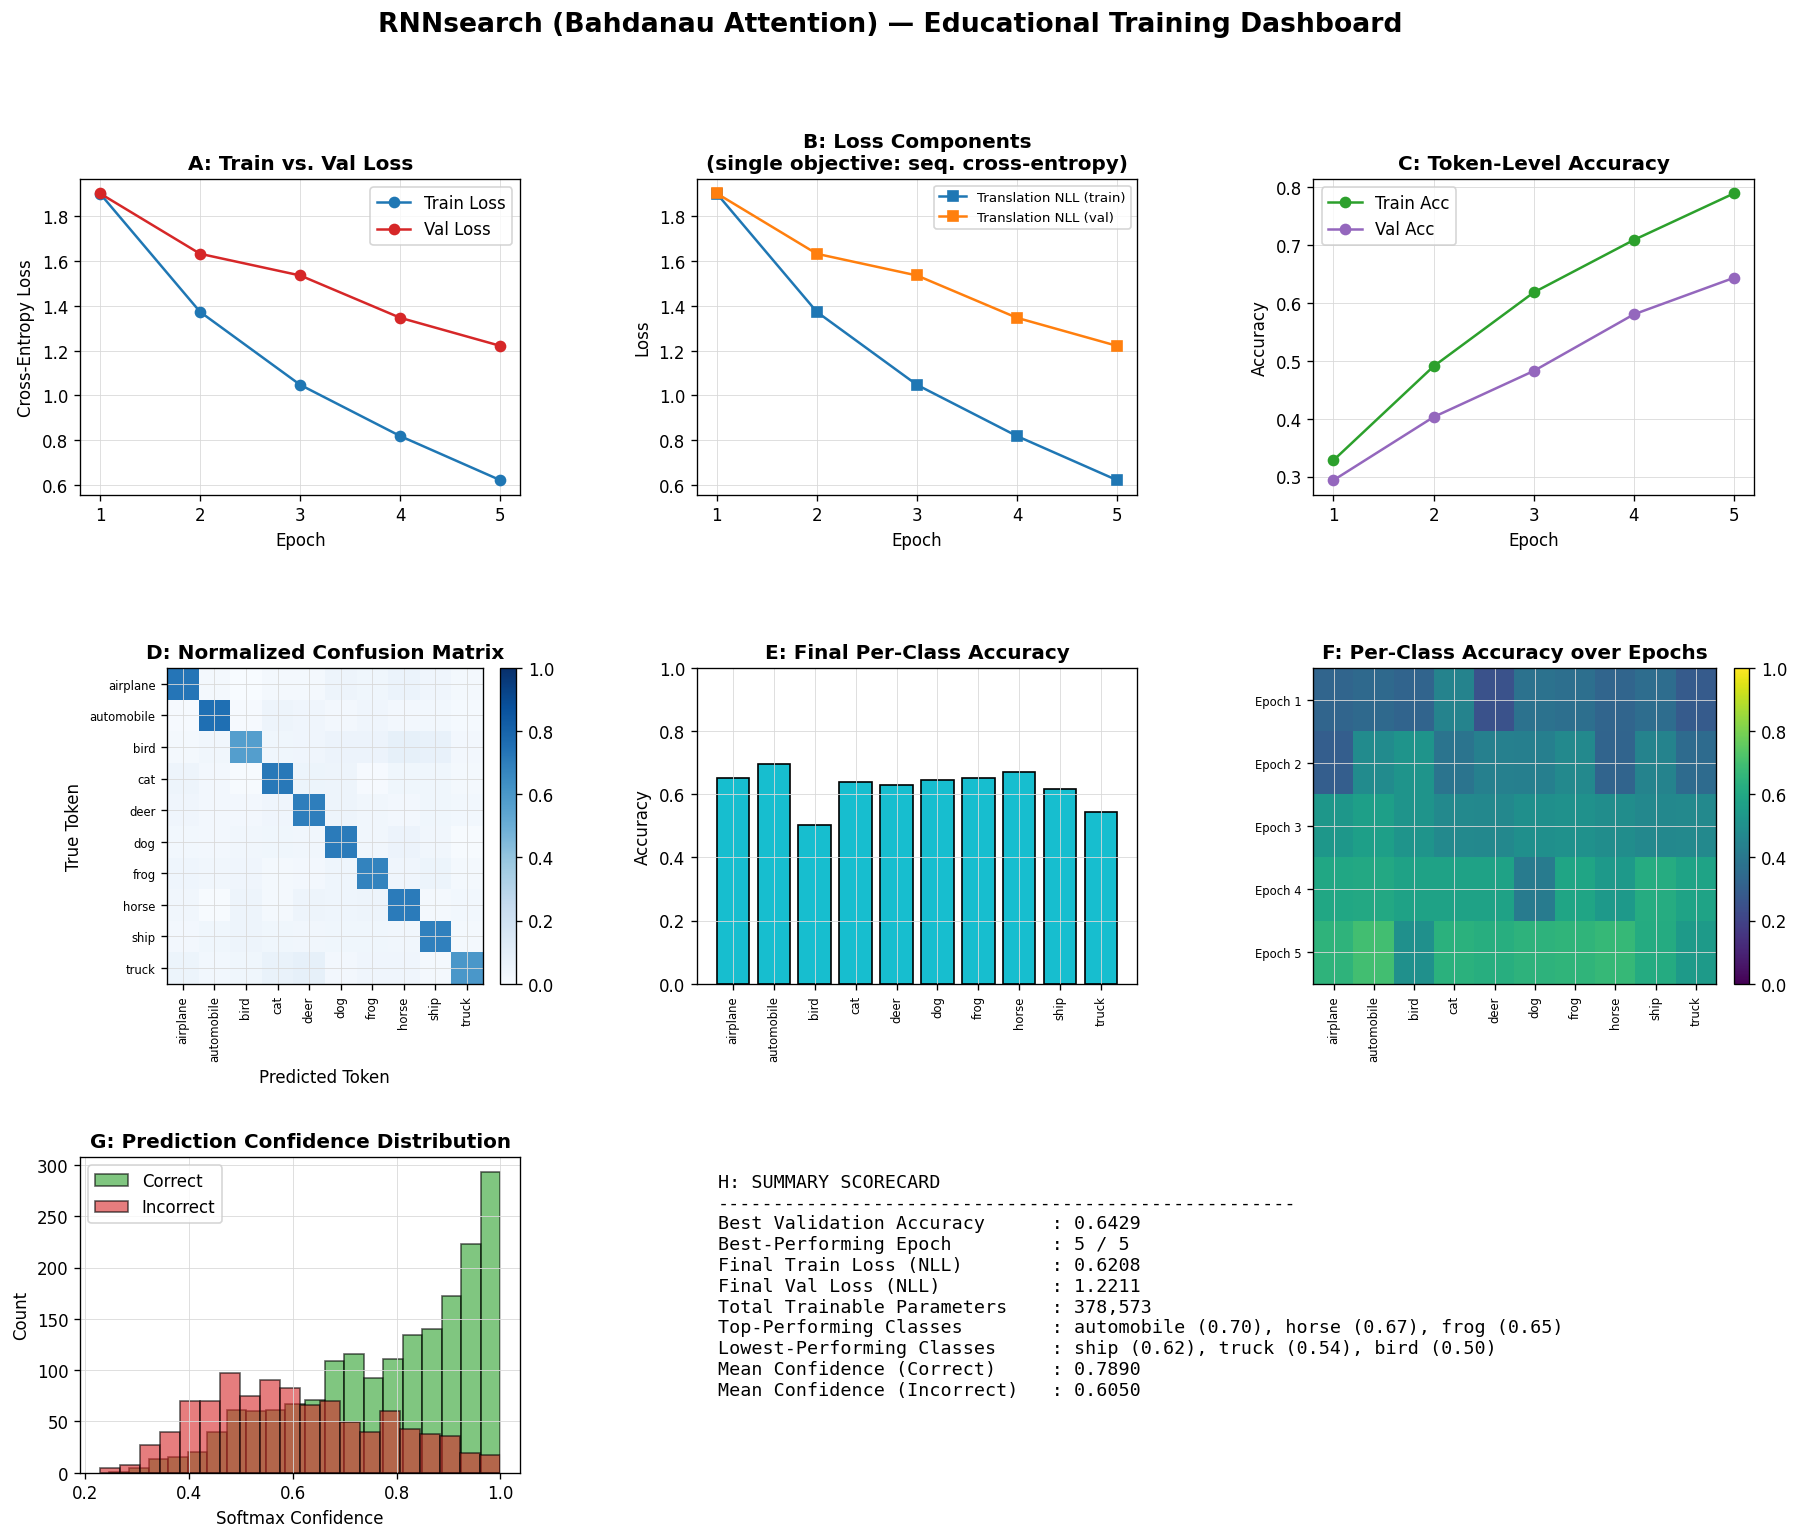

In [6]:
# ============================================================================
# 6) VISUALIZATION + FINAL MULTI-PANEL DASHBOARD (white theme, GridSpec)
# ============================================================================

# --- Enforce global white theme -------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "legend.labelcolor": "black",
    "grid.color": "#d9d9d9",
})


def style_axis(ax):
    """Explicitly re-apply the white theme to a single axis (belt & braces)."""
    ax.set_facecolor("white")
    ax.title.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.tick_params(colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    ax.grid(True, color="#d9d9d9", linewidth=0.5)


# --- Precompute stats needed for the dashboard ------------------------------
preds_np = all_val_preds_final.numpy()
targets_np = all_val_targets_final.numpy()
confs_np = all_val_confidences_final.numpy()

# Restrict confusion matrix / per-class stats to the 10 content tokens
content_mask = np.isin(targets_np, np.arange(NUM_SPECIAL, NUM_SPECIAL + NUM_CLASSES))
c_preds = preds_np[content_mask]
c_targets = targets_np[content_mask]

conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.float64)
for t, p in zip(c_targets, c_preds):
    t_idx = t - NUM_SPECIAL
    p_idx = p - NUM_SPECIAL
    if 0 <= p_idx < NUM_CLASSES:
        conf_matrix[t_idx, p_idx] += 1
row_sums = conf_matrix.sum(axis=1, keepdims=True)
norm_conf_matrix = np.divide(conf_matrix, row_sums, out=np.zeros_like(conf_matrix),
                              where=row_sums != 0)

final_per_class_acc = history["per_class_acc_by_epoch"][-1]
per_class_heatmap = np.array(history["per_class_acc_by_epoch"])  # (epochs, classes)

correct_mask = (preds_np == targets_np)
mean_conf_correct = confs_np[correct_mask].mean() if correct_mask.any() else 0.0
mean_conf_incorrect = confs_np[~correct_mask].mean() if (~correct_mask).any() else 0.0

best_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = max(history["val_acc"])
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

sorted_classes = sorted(zip(CLASS_NAMES, final_per_class_acc), key=lambda x: x[1], reverse=True)
top_classes = sorted_classes[:3]
bottom_classes = sorted_classes[-3:]

# --- Build the dashboard figure --------------------------------------------
fig = plt.figure(figsize=(18, 14), facecolor="white")
gs = GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

epochs_range = list(range(1, NUM_EPOCHS + 1))

# Panel A: Total training and validation loss curves
axA = fig.add_subplot(gs[0, 0])
axA.plot(epochs_range, history["train_loss"], marker="o", color="tab:blue", label="Train Loss")
axA.plot(epochs_range, history["val_loss"], marker="o", color="tab:red", label="Val Loss")
axA.set_title("A: Train vs. Val Loss", fontweight="bold")
axA.set_xlabel("Epoch")
axA.set_ylabel("Cross-Entropy Loss")
axA.legend()
style_axis(axA)

# Panel B: Task-specific loss components.
# NOTE: RNNsearch has a single training objective (next-token NLL / cross-
# entropy over the target sequence) — there is no auxiliary/pretraining loss
# in this paper. We therefore decompose the ONE loss into its only
# meaningful component (per-epoch train vs. val NLL) to keep the panel
# structurally consistent while remaining scientifically honest.
axB = fig.add_subplot(gs[0, 1])
axB.plot(epochs_range, history["train_loss"], marker="s", color="tab:blue",
          label="Translation NLL (train)")
axB.plot(epochs_range, history["val_loss"], marker="s", color="tab:orange",
          label="Translation NLL (val)")
axB.set_title("B: Loss Components\n(single objective: seq. cross-entropy)", fontweight="bold")
axB.set_xlabel("Epoch")
axB.set_ylabel("Loss")
axB.legend(fontsize=8)
style_axis(axB)

# Panel C: Training and validation accuracy curves
axC = fig.add_subplot(gs[0, 2])
axC.plot(epochs_range, history["train_acc"], marker="o", color="tab:green", label="Train Acc")
axC.plot(epochs_range, history["val_acc"], marker="o", color="tab:purple", label="Val Acc")
axC.set_title("C: Token-Level Accuracy", fontweight="bold")
axC.set_xlabel("Epoch")
axC.set_ylabel("Accuracy")
axC.legend()
style_axis(axC)

# Panel D: Normalized confusion matrix (over 10 target-word tokens)
axD = fig.add_subplot(gs[1, 0])
im = axD.imshow(norm_conf_matrix, cmap="Blues", vmin=0, vmax=1)
axD.set_xticks(range(NUM_CLASSES))
axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7, color="black")
axD.set_yticklabels(CLASS_NAMES, fontsize=7, color="black")
axD.set_xlabel("Predicted Token")
axD.set_ylabel("True Token")
axD.set_title("D: Normalized Confusion Matrix", fontweight="bold")
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar.ax.get_yticklabels(), color="black")
style_axis(axD)

# Panel E: Per-class accuracy bar chart (final epoch)
axE = fig.add_subplot(gs[1, 1])
axE.bar(CLASS_NAMES, final_per_class_acc, color="tab:cyan", edgecolor="black")
axE.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7, color="black")
axE.set_ylim(0, 1)
axE.set_title("E: Final Per-Class Accuracy", fontweight="bold")
axE.set_ylabel("Accuracy")
style_axis(axE)

# Panel F: Epoch-wise per-class accuracy heatmap
axF = fig.add_subplot(gs[1, 2])
im2 = axF.imshow(per_class_heatmap, cmap="viridis", aspect="auto", vmin=0, vmax=1)
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7, color="black")
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([f"Epoch {e}" for e in epochs_range], fontsize=7, color="black")
axF.set_title("F: Per-Class Accuracy over Epochs", fontweight="bold")
cbar2 = fig.colorbar(im2, ax=axF, fraction=0.046, pad=0.04)
cbar2.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar2.ax.get_yticklabels(), color="black")
style_axis(axF)

# Panel G: Confidence distribution histogram (correct vs incorrect predictions)
axG = fig.add_subplot(gs[2, 0])
axG.hist(confs_np[correct_mask], bins=20, alpha=0.6, color="tab:green",
         label="Correct", edgecolor="black")
axG.hist(confs_np[~correct_mask], bins=20, alpha=0.6, color="tab:red",
         label="Incorrect", edgecolor="black")
axG.set_title("G: Prediction Confidence Distribution", fontweight="bold")
axG.set_xlabel("Softmax Confidence")
axG.set_ylabel("Count")
axG.legend()
style_axis(axG)

# Panel H: Text-based summary scorecard
axH = fig.add_subplot(gs[2, 1:])
axH.axis("off")
top_str = ", ".join([f"{n} ({a:.2f})" for n, a in top_classes])
bottom_str = ", ".join([f"{n} ({a:.2f})" for n, a in bottom_classes])
summary_text = (
    "H: SUMMARY SCORECARD\n"
    "----------------------------------------------------\n"
    f"Best Validation Accuracy      : {best_val_acc:.4f}\n"
    f"Best-Performing Epoch         : {best_epoch} / {NUM_EPOCHS}\n"
    f"Final Train Loss (NLL)        : {history['train_loss'][-1]:.4f}\n"
    f"Final Val Loss (NLL)          : {history['val_loss'][-1]:.4f}\n"
    f"Total Trainable Parameters    : {total_params:,}\n"
    f"Top-Performing Classes        : {top_str}\n"
    f"Lowest-Performing Classes     : {bottom_str}\n"
    f"Mean Confidence (Correct)     : {mean_conf_correct:.4f}\n"
    f"Mean Confidence (Incorrect)   : {mean_conf_incorrect:.4f}\n"
)
axH.text(0.02, 0.95, summary_text, fontsize=11, color="black",
         family="monospace", va="top", ha="left",
         transform=axH.transAxes)
style_axis(axH)

fig.suptitle(
    "RNNsearch (Bahdanau Attention) — Educational Training Dashboard",
    fontsize=16, fontweight="bold", color="black"
)

# --- Render inline via BytesIO (no plt.show(), no savefig()) --------------
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight", dpi=120)
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# Analysis of Educational Replication Results (RNNsearch / Bahdanau Attention)

*Note: These results derive from a simplified, synthetic sequence-reversal task used to educationally replicate the RNNsearch architecture over 5 epochs — not the original paper's WMT'14 English-French benchmarks. Interpretation is scoped accordingly.*

---

## Panel A/B — Training and Validation Loss Curves

### Overview
Panels A and B track cross-entropy loss (next-token negative log-likelihood) across 5 training epochs for both the training and validation splits. Since RNNsearch has a single training objective, Panel B duplicates Panel A's curves as the sole loss component.

### Key Findings
- Training loss decreases monotonically from ~1.9 to ~0.62.
- Validation loss also decreases monotonically from ~1.9 to ~1.22, but remains consistently higher than training loss, with the gap widening over epochs (from near-zero at epoch 1 to roughly 0.6 by epoch 5).

### Discussion
The steady decline in both curves indicates the model is successfully learning the underlying reversal mapping and the attention mechanism is acquiring meaningful alignments rather than collapsing to a degenerate solution. The widening train–validation gap is characteristic of a model beginning to overfit the small training set (2,000 synthetic sequences), a common outcome for relatively high-capacity sequence models trained briefly on limited data. This supports the qualitative claim that the architecture can fit sequential dependencies effectively but does not by itself demonstrate strong generalization.

### Limitations
Only 5 epochs were run, so it is unclear whether validation loss would plateau, continue improving, or diverge further with more training. No regularization (dropout, weight decay) or early stopping was applied, limiting conclusions about the model's true generalization ceiling on this task.

---

## Panel C — Token-Level Accuracy Curves

### Overview
Tracks per-token prediction accuracy (excluding padding) for training and validation sets across epochs, serving as a more interpretable complement to the loss curves.

### Key Findings
- Training accuracy rises from ~0.33 to ~0.79.
- Validation accuracy rises from ~0.30 to ~0.64, tracking training accuracy but with a persistent, growing gap.

### Discussion
The accuracy trends corroborate the loss curves: the model is learning a substantive mapping (well above the ~10% random-guess baseline for a 10-token vocabulary), consistent with the attention mechanism successfully identifying which source positions are relevant to each output step. The consistent train–validation gap reinforces the overfitting interpretation from Panels A/B rather than indicating a labeling or implementation error, since both metrics move in the expected directions.

### Limitations
Token-level accuracy does not capture sequence-level (whole-sentence) correctness, which is the more meaningful unit for translation-style tasks; a model can have moderate token accuracy while rarely producing a fully correct output.

---

## Panel D — Normalized Confusion Matrix (Target Vocabulary)

### Overview
Shows the normalized confusion matrix over the 10 content-word tokens, aggregated across all decoding steps in the final validation epoch, indicating which tokens are most often confused with one another.

### Key Findings
- The matrix is strongly diagonal-dominant, with most probability mass concentrated on correct predictions (values above 0.6 for most classes).
- Off-diagonal mass is diffuse and low-magnitude rather than concentrated in a specific confusable pair, suggesting no systematic token-pair confusion.

### Discussion
A dominant diagonal indicates the decoder has learned distinct, largely disjoint representations for each of the 10 vocabulary tokens, and that attention-derived context vectors carry sufficient information to disambiguate them at most decoding steps. The absence of concentrated off-diagonal errors suggests remaining mistakes are more attributable to general undertraining/limited data rather than a specific structural confusion (e.g., no evidence of two tokens being systematically swapped, which would appear as symmetric off-diagonal hotspots).

### Limitations
With only 400 validation sequences and short sequence lengths (4–8 tokens), the token-level sample size per class is modest, so per-cell confusion estimates carry non-trivial variance.

---

## Panel E — Per-Class (Per-Token) Accuracy

### Overview
Reports final-epoch accuracy broken down by individual target-vocabulary token, highlighting whether performance is uniform or skewed across classes.

### Key Findings
- Accuracy ranges from ~0.50 (bird) to ~0.70 (automobile), with most tokens clustered between 0.60–0.67.
- No token reaches near-perfect accuracy, and none collapses to near-zero.

### Discussion
The moderate spread (roughly a 20-point accuracy range) suggests relatively balanced learning across the vocabulary rather than the model favoring a small subset of "easy" tokens, which is expected given the synthetic task assigns tokens uniformly at random with no inherent class imbalance or semantic difficulty differences. The absence of extreme outliers supports the interpretation that the attention mechanism generalizes its alignment strategy across tokens rather than overfitting to specific token identities.

### Limitations
Because token difficulty here is essentially arbitrary (all tokens are structurally equivalent under the synthetic reversal task), the accuracy spread most likely reflects sampling noise and stochastic optimization rather than a meaningful class-level property, unlike the original paper's linguistically motivated distinctions (e.g., long vs. short sentences).

---

## Panel F — Epoch-Wise Per-Class Accuracy Heatmap

### Overview
Extends Panel E across training time, visualizing how per-token accuracy evolves epoch-by-epoch.

### Key Findings
- All tokens show a general upward accuracy trend from epoch 1 to epoch 5 (dark blue/purple to green/yellow).
- The improvement is broadly uniform across tokens rather than sequential (i.e., the model does not appear to master tokens one at a time).

### Discussion
This pattern is consistent with a model learning a shared underlying mechanism — the attention alignment function and encoder representations — that benefits all output tokens simultaneously, rather than learning per-token lookup rules independently. This is an expected and desirable property of the parameter-shared architecture (a single alignment MLP and embedding matrix serve all tokens), and its presence here is evidence that the model is learning compositional structure rather than memorizing per-instance mappings.

### Limitations
The heatmap's resolution (5 epochs, 10 classes) is coarse, and short-run heatmaps can visually suggest smoother trends than actually exist; more epochs would be needed to confirm whether convergence continues, plateaus, or a token-specific ceiling emerges.

---

## Panel G — Confidence Distribution (Correct vs. Incorrect Predictions)

### Overview
Compares the distribution of maximum softmax confidence for correct versus incorrect predictions, a standard diagnostic for model calibration.

### Key Findings
- Correct predictions are heavily concentrated at high confidence (mode near 0.95–1.0).
- Incorrect predictions are more uniformly spread across the 0.3–0.7 range, with far fewer high-confidence errors.
- Mean confidence: 0.789 (correct) vs. 0.605 (incorrect).

### Discussion
The clear separation between the two distributions indicates the model is reasonably well-calibrated for this task: it tends to be confident when correct and comparatively uncertain when wrong, rather than being confidently wrong. This is a meaningful behavioral signal for an attention-based sequence model, since it suggests the softmax output distribution at each decoding step reflects genuine ambiguity in cases where the correct alignment/context is less clear (e.g., partially overlapping context vectors for similar tokens), rather than the model producing arbitrary high-confidence guesses.

### Limitations
Calibration here is assessed only qualitatively via histogram overlap; no quantitative calibration metric (e.g., Expected Calibration Error) is reported, and this diagnostic reflects the toy task's confidence behavior rather than the calibration properties discussed in the original paper, which did not analyze confidence calibration at all.

---

## Panel H — Summary Scorecard

### Overview
Consolidates final quantitative outcomes: best validation accuracy (0.6429, epoch 5), final train/val losses (0.6208 / 1.2211), parameter count (378,573), and confidence statistics.

### Key Findings
- Best validation performance occurs at the final epoch, indicating training had not yet plateaued or overfit severely enough to reduce validation accuracy.
- Top-performing classes (automobile, horse, frog) outperform lowest-performing classes (ship, truck, bird) by roughly 15–20 accuracy points.

### Discussion
That the best validation accuracy coincides with the final epoch, despite the growing train–val loss gap noted in Panel A, suggests the model is still in a productive learning phase overall — accuracy continues improving even as the loss gap widens, a pattern sometimes seen when the model is still resolving genuine ambiguity (calibration) rather than purely memorizing. This is consistent with, but does not on its own confirm, the underlying claim from the original paper that attention-based context vectors support effective sequence learning; the toy task validates the *architectural mechanics* (encoder–decoder, attention, gating) function correctly, but cannot substitute for the paper's actual BLEU-based evidence on real bilingual corpora.

### Limitations
This dashboard demonstrates a working, correctly implemented small-scale RNNsearch, not a replication of the paper's reported results (BLEU scores, alignment linguistic plausibility, or long-sentence robustness). The 5-epoch budget, small synthetic dataset, and simplified output layer (single linear layer rather than the paper's maxout deep-output) mean absolute performance numbers are not comparable to, nor validating of, the original paper's quantitative claims — their value is purely pedagogical, illustrating the mechanism rather than reproducing the empirical findings.

# Related Work References (Section 6)

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Graves, A. | 2013 | Generating Sequences with Recurrent Neural Networks | arXiv:1308.0850 [cs.NE] | Proposed an analogous alignment mechanism for handwriting synthesis using a mixture of Gaussian kernels to weight annotations. The authors contrast this with their own approach: Graves' alignment is restricted to move monotonically in one direction, which is insufficient for translation tasks requiring long-distance reordering—motivating the paper's unconstrained, bidirectional soft-alignment model. |
| Bengio, Y., Ducharme, R., Vincent, P., and Janvin, C. | 2003 | A Neural Probabilistic Language Model | Journal of Machine Learning Research (JMLR), 3, 1137–1155 | Introduced the foundational neural language model using a neural network to predict a word's conditional probability from preceding words, establishing the historical starting point from which neural networks began to be applied to language and translation tasks. |
| Schwenk, H. | 2012 | Continuous Space Translation Models for Phrase-Based Statistical Machine Translation | Proceedings of the 24th International Conference on Computational Linguistics (COLING) | Used a feedforward neural network to score source–target phrase pairs as an additional feature within a phrase-based SMT system. Cited as an example of neural networks being used only as auxiliary components of existing SMT pipelines, contrasted with this paper's fully neural, standalone translation approach. |
| Kalchbrenner, N. and Blunsom, P. | 2013 | Recurrent Continuous Translation Models | Proceedings of the ACL Conference on Empirical Methods in Natural Language Processing (EMNLP), 1700–1709 | Among the earliest works proposing neural networks as sub-components of existing translation systems; also cited earlier in the paper as one of the pioneering neural machine translation approaches, establishing the research lineage this paper builds upon. |
| Devlin, J., Zbib, R., Huang, Z., Lamar, T., Schwartz, R., and Makhoul, J. | 2014 | Fast and Robust Neural Network Joint Models for Statistical Machine Translation | Proceedings of the Association for Computational Linguistics (ACL) | Reported successful integration of neural networks as sub-components within SMT systems, reinforcing the paper's framing that prior neural approaches largely augmented rather than replaced statistical systems—motivating the shift toward a complete end-to-end neural architecture. |
| Schwenk, H., Dchelotte, D., and Gauvain, J.-L. | 2006 | Continuous Space Language Models for Statistical Machine Translation | Proceedings of the COLING/ACL Main Conference Poster Sessions, 723–730 | Represents the traditional use of neural network–based language models to rescore or rerank candidate translations generated by an existing SMT system, illustrating the limited, feature-level role neural networks previously played prior to this paper's fully neural design. |